In [1]:
from vanna.openai.openai_chat import OpenAI_Chat
from vanna.chromadb.chromadb_vector import ChromaDB_VectorStore
import os
from dotenv import load_dotenv
load_dotenv()
api_key = os.getenv("VANNA_API_KEY")
OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
OPENAI_MODEL = "gpt-4o-mini"


In [ ]:
from sqlalchemy import create_engine, text
import pandas as pd


In [ ]:


# Load your SQLite database file
engine = create_engine("sqlite:///data/participants.db")

# Query to get schema objects and their creation SQL
query = text("SELECT type, sql FROM sqlite_master WHERE sql IS NOT NULL")

# Run the query and print results
with engine.connect() as conn:
    result = conn.execute(query)
    for row in result:
        print(f"{row.type.upper()}: {row.sql}\n")

    SP ID  Gender   Age Work Experience/From Date Work Experience/To Date  \
0  623114  Female  24.0                        NA                      NA   
1  621593    Male  23.0                2022-08-17              2023-08-15   
2  621593    Male  23.0                2024-01-02              2024-07-25   
3  621290  Female  30.0                        NA                      NA   
4  620894    Male  34.0                        NA                      NA   

                 Languages  
0  Hindi / हिंदी (R W S T)  
1   English (UK) (R W S T)  
2   English (UK) (R W S T)  
3   English (IN) (R W S T)  
4  Hindi / हिंदी (R W S T)  


In [2]:
class MyVanna(ChromaDB_VectorStore, OpenAI_Chat):
    def __init__(self, config=None):
        ChromaDB_VectorStore.__init__(self, config=config)
        OpenAI_Chat.__init__(self, config=config)

vn = MyVanna(config={"api_key": OPENAI_API_KEY, 'model': OPENAI_MODEL, "temperature": 0.0})

In [4]:
vn.connect_to_sqlite("data/participants.db")

In [5]:
df_ddl = vn.run_sql("SELECT type, sql FROM sqlite_master WHERE sql is not null")

In [6]:
for ddl in df_ddl['sql'].to_list():
    #print(ddl)
    vn.train(ddl=ddl)

Adding ddl: CREATE TABLE participants_structured (
	"SP ID" BIGINT, 
	"Gender" TEXT, 
	"Age" FLOAT, 
	"Work Experience/From Date" TEXT, 
	"Work Experience/To Date" TEXT, 
	"Languages" TEXT
)


/Users/adrianmarkelov/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz: 100%|██████████| 79.3M/79.3M [00:47<00:00, 1.75MiB/s]


Adding ddl: CREATE TABLE participants_unstructured (
	"SP ID" BIGINT, 
	"Work Experience/Company" TEXT, 
	"Work Experience/Designation" TEXT, 
	"Work Experience/Tasks" TEXT, 
	"Work Experience/Industry" TEXT, 
	"Education/Qualifications" TEXT, 
	"Education/Specialization" TEXT, 
	"Any Additional Skills" TEXT, 
	"Computer Skills" TEXT, 
	"Skills" TEXT, 
	"Languages" TEXT
)


In [7]:
training_data = vn.get_training_data()
print(training_data)

                                         id question  \
0  19948383-a6a5-536e-b80b-5e4fbe795a7c-ddl     None   
1  3e17f3fb-bb4c-53bb-88e0-13e0977a8647-ddl     None   

                                             content training_data_type  
0  CREATE TABLE participants_structured (\n\t"SP ...                ddl  
1  CREATE TABLE participants_unstructured (\n\t"S...                ddl  


Number of requested results 10 is greater than number of elements in index 2, updating n_results = 2


SQL Prompt: [{'role': 'system', 'content': 'You are a SQLite expert. Please help to generate a SQL query to answer the question. Your response should ONLY be based on the given context and follow the response guidelines and format instructions. \n===Tables \nCREATE TABLE participants_unstructured (\n\t"SP ID" BIGINT, \n\t"Work Experience/Company" TEXT, \n\t"Work Experience/Designation" TEXT, \n\t"Work Experience/Tasks" TEXT, \n\t"Work Experience/Industry" TEXT, \n\t"Education/Qualifications" TEXT, \n\t"Education/Specialization" TEXT, \n\t"Any Additional Skills" TEXT, \n\t"Computer Skills" TEXT, \n\t"Skills" TEXT, \n\t"Languages" TEXT\n)\n\nCREATE TABLE participants_structured (\n\t"SP ID" BIGINT, \n\t"Gender" TEXT, \n\t"Age" FLOAT, \n\t"Work Experience/From Date" TEXT, \n\t"Work Experience/To Date" TEXT, \n\t"Languages" TEXT\n)\n\n===Response Guidelines \n1. If the provided context is sufficient, please generate a valid SQL query without any explanations for the question. \n2. If the p

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


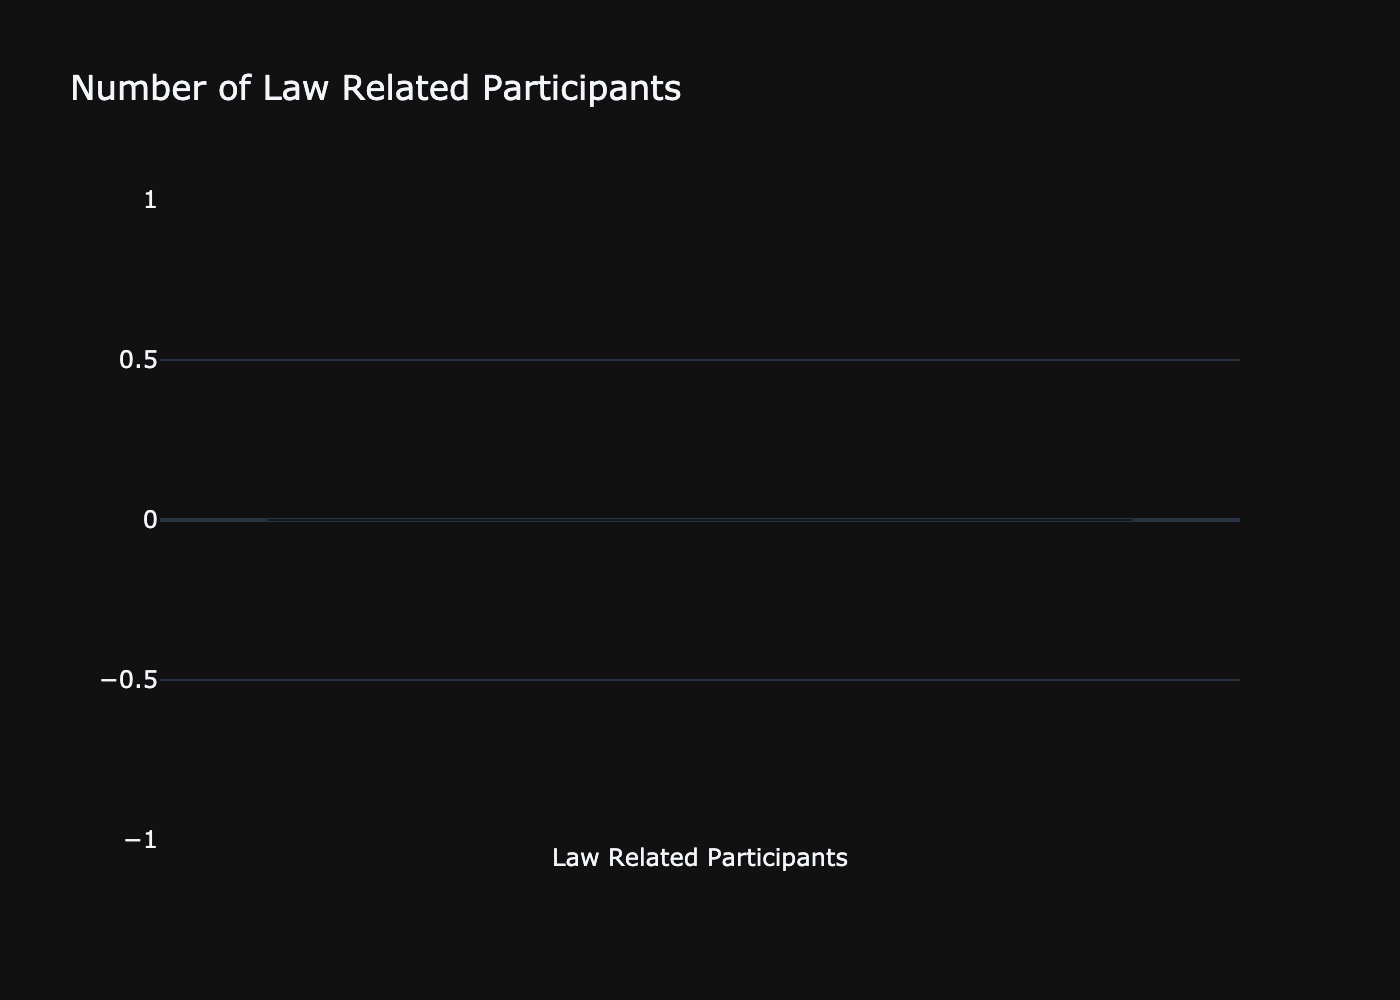

('SELECT COUNT(*) \nFROM participants_unstructured \nWHERE "Work Experience/Industry" LIKE \'%law%\';',
    COUNT(*)
 0         0,
 Figure({
     'data': [{'type': 'bar', 'x': ['Law Related Participants'], 'y': [0]}],
     'layout': {'template': '...', 'title': {'text': 'Number of Law Related Participants'}}
 }))

In [ ]:
vn.ask(question="?")